<a href="https://colab.research.google.com/github/adriananevex/eda/blob/main/2_2_EDA_Alula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import  pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_original = sns.load_dataset('penguins')

In [ ]:
df = df_original.copy()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


In [ ]:
#Dicionario de Dados
#Entendimento dos dados e informacoes de metadados

In [ ]:
numeric_cols = df.select_dtypes('float64')
numeric_cols

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [ ]:
categorical_cols = df.select_dtypes('object')
categorical_cols

,species,island,sex
0,Adelie,Torgersen,Male
1,Adelie,Torgersen,Female
2,Adelie,Torgersen,Female
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,Female
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,Female
341,Gentoo,Biscoe,Male
342,Gentoo,Biscoe,Female


In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
#df.describe(include = 'object)
categorical_cols.describe()

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


In [ ]:
categorical_cols_list = df.select_dtypes('object').columns.tolist()
categorical_cols_list

['species', 'island', 'sex']

In [ ]:
df[categorical_cols_list].describe()

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


In [ ]:
#cria um novo apontamento para ler o df
df_clean = df

In [ ]:
duplicados = df_clean.duplicated().sum()
print(f'Numero de linhas duplicadas: {duplicados}')

Numero de linhas duplicadas: 0


In [ ]:
#consultar dados em falta
df_clean.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
#calcular percentagem dos dados em falta
missing_perc = df_clean.isnull().mean()*100
missing_perc.round(2)

,0
species,0.00
island,0.00
bill_length_mm,0.58
bill_depth_mm,0.58
flipper_length_mm,0.58
body_mass_g,0.58
sex,3.20


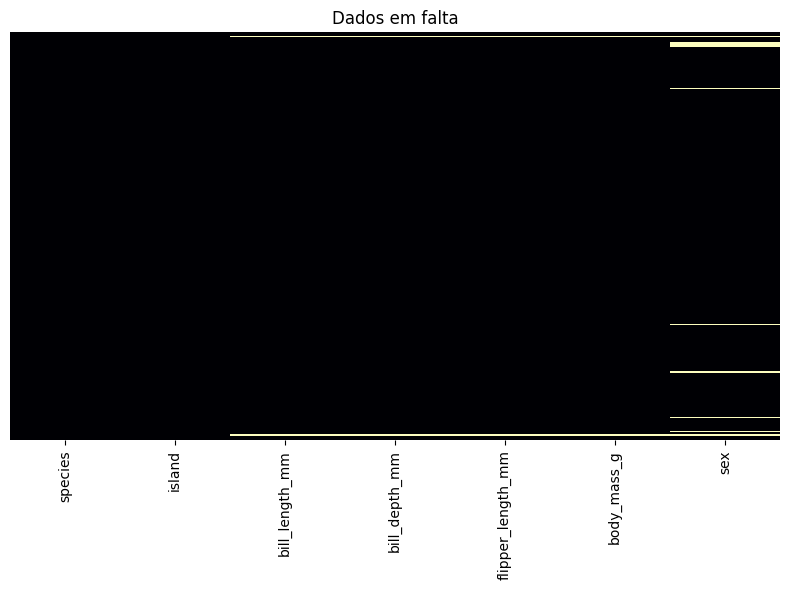

In [ ]:
plt.figure(figsize= (8,6))

sns.heatmap(df_clean.isnull(), cbar = False, yticklabels = False, cmap = 'magma')
plt.title('Dados em falta')
plt.tight_layout()
plt.show()


📊 MATRIZ DE MISSINGNESS



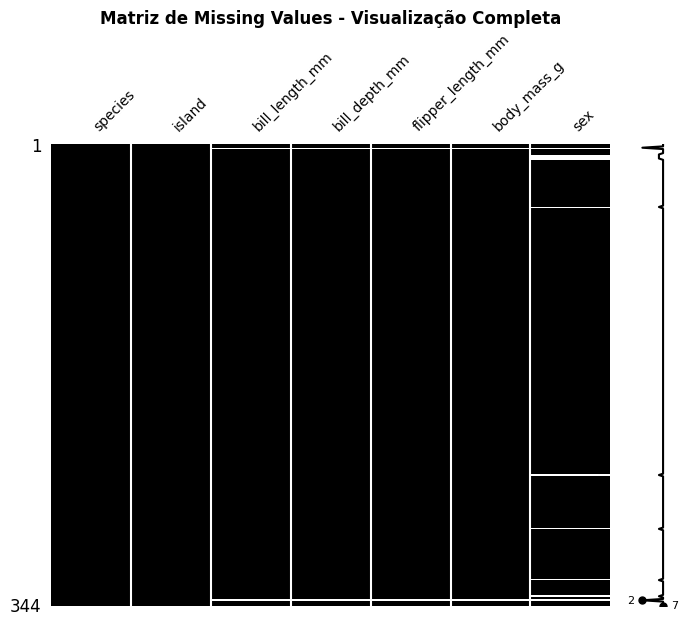

In [ ]:
import missingno as msno
# MATRIZ DE MISSINGNESS (a mais útil)
print('\n📊 MATRIZ DE MISSINGNESS\n')

msno.matrix(df_original, figsize=(8, 6), fontsize= 10, color=(0, 0, 0))
plt.title('Matriz de Missing Values - Visualização Completa', fontsize=12, fontweight='bold')
plt.show()

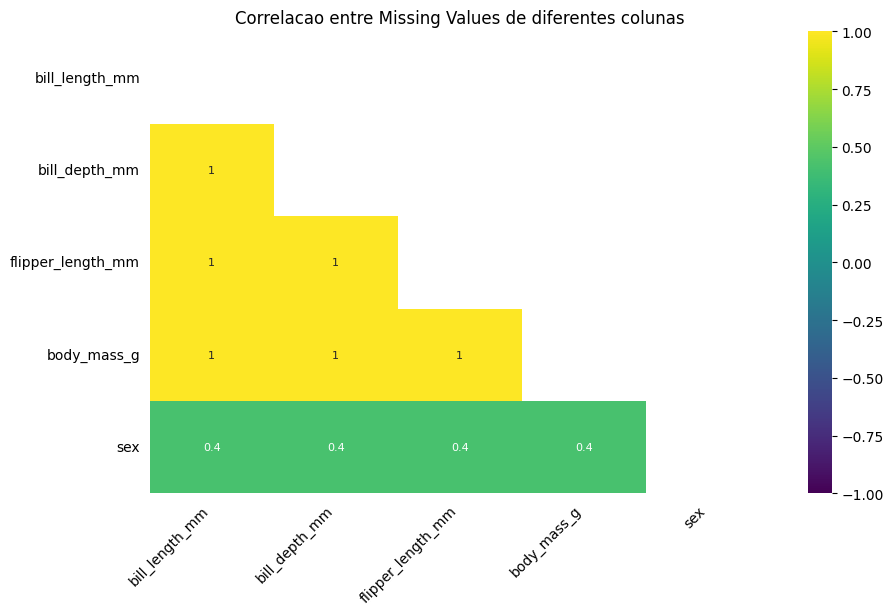

In [ ]:
msno.heatmap(df_clean, figsize=(10,6), fontsize= 10, cmap = 'viridis')
plt.title('Correlacao entre Missing Values de diferentes colunas', fontsize=12)
plt.show()

In [ ]:
print('💡 INTERPRETAÇÃO DO HEATMAP:')
print('  • Valores próximos de 1 = Colunas que faltam JUNTAS')
print('  • Valores próximos de -1 = Colunas que faltam SEPARADAMENTE')
print('  • Valores próximos de 0 = Sem correlação no missingness')

💡 INTERPRETAÇÃO DO HEATMAP:
  • Valores próximos de 1 = Colunas que faltam JUNTAS
  • Valores próximos de -1 = Colunas que faltam SEPARADAMENTE
  • Valores próximos de 0 = Sem correlação no missingness


In [ ]:
# Imputacao simples na variavel SEX

In [ ]:
sex_before = df_clean['sex'].value_counts(dropna=False)
print(sex_before)

#imputacao
moda_sex = df_clean.sex.mode()[0]
df_clean['sex_imputed'] = df_clean.sex.fillna(moda_sex)

sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64


In [ ]:
sex_after= df_clean['sex_imputed'].value_counts(dropna=False)
print(sex_after)

sex_imputed
Male      179
Female    165
Name: count, dtype: int64


In [ ]:
moda_sex

'Male'

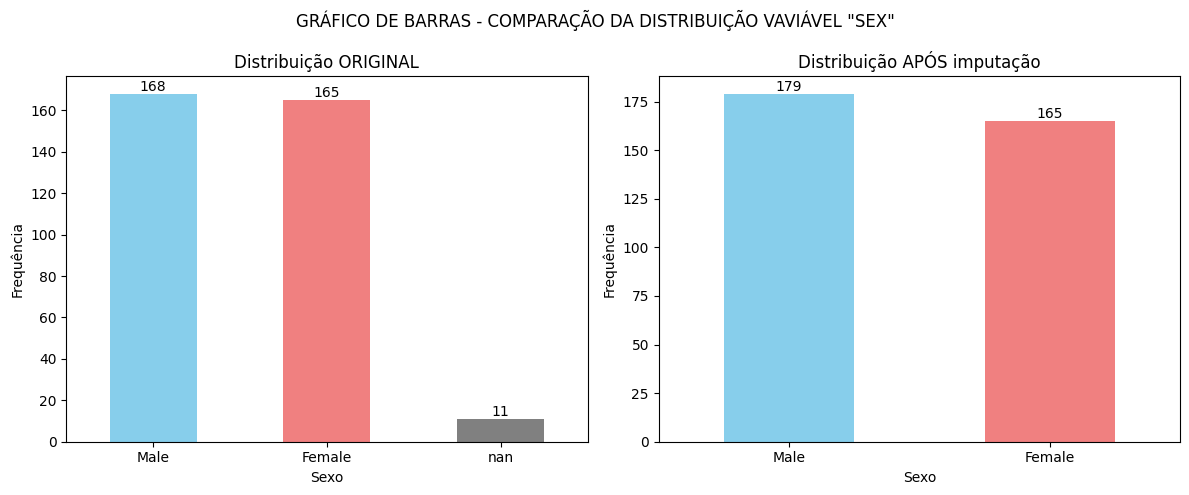

In [ ]:
# Criar figura com dois subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# GRÁFICO DE BARRAS 1: Distribuição antes da imputação (incluindo missing values)
df_clean['sex'].value_counts(dropna=False).plot(kind='bar', color=['skyblue', 'lightcoral', 'gray'], ax=ax1)
ax1.set_title('Distribuição ORIGINAL')
ax1.set_xlabel('Sexo')
ax1.set_ylabel('Frequência')

# tick_params permite rodar os lables
ax1.tick_params(axis='x', rotation= 0)

# Adicionar valores nas barras
ax1.bar_label(ax1.containers[0])

# GRÁFICO DE BARRAS 2: Distribuição após imputação
df_clean['sex_imputed'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'], ax=ax2)
ax2.set_title('Distribuição APÓS imputação')
ax2.set_xlabel('Sexo')
ax2.set_ylabel('Frequência')

# tick_params permite rodar os lables
ax2.tick_params(axis='x', rotation= 0)

# Adicionar valores nas barras - FORMA SIMPLES
ax2.bar_label(ax2.containers[0])

plt.suptitle('GRÁFICO DE BARRAS - COMPARAÇÃO DA DISTRIBUIÇÃO VAVIÁVEL "SEX"')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
total_observations = len(df_clean)

print('ESTATÍSTICAS ANTES DA IMPUTAÇÃO:')
print(f'   • Total de observações: {total_observations}')
print(f'   • Female: {sex_before.get("Female", 0)} ({sex_before.get("Female", 0)/total_observations:.1%})')
print(f'   • Male: {sex_before.get("Male", 0)} ({sex_before.get("Male", 0)/total_observations:.1%})')
print(f'   • Missing: {sex_before.get(np.nan, 0)} ({sex_before.get(np.nan, 0)/total_observations:.1%})')


print('\n------------------------------------\n')
print('ESTATÍSTICAS DEPOIS DA IMPUTAÇÃO:')
print(f'   • Total de observações: {total_observations}')
print(f'   • Female: {sex_after.get("Female", 0)} ({sex_after.get("Female", 0)/total_observations:.1%})')
print(f'   • Male: {sex_after.get("Male", 0)} ({sex_after.get("Male", 0)/total_observations:.1%})')
print(f'   • Missing: {df_clean["sex_imputed"].isnull().sum()} ({df_clean["sex_imputed"].isnull().sum()/total_observations:.1%})')

print('\n------------------------------------\n')
# Calcular mudança nas proporções
if 'Female' in sex_before and 'Female' in sex_after:
    female_change = (sex_after['Female'] - sex_before['Female']) / sex_before['Female'] * 100
    male_change = (sex_after['Male'] - sex_before['Male']) / sex_before['Male'] * 100

    print('MUDANÇAS NAS PROPORÇÕES:')
    print(f'   • Female: {female_change:+.2f}%')
    print(f'   • Male: {male_change:+.2f}%')

ESTATÍSTICAS ANTES DA IMPUTAÇÃO:
   • Total de observações: 344
   • Female: 165 (48.0%)
   • Male: 168 (48.8%)
   • Missing: 11 (3.2%)

------------------------------------

ESTATÍSTICAS DEPOIS DA IMPUTAÇÃO:
   • Total de observações: 344
   • Female: 165 (48.0%)
   • Male: 179 (52.0%)
   • Missing: 0 (0.0%)

------------------------------------

MUDANÇAS NAS PROPORÇÕES:
   • Female: +0.00%
   • Male: +6.55%


In [ ]:
#Nao existe uma alteracao significativa na distribuiao dos dados

In [ ]:
#Imputacao basia das variaveis numericas

In [ ]:
numeric_cols_list = numeric_cols.columns.tolist()
numeric_cols_list

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [ ]:
medias_before = df_clean[numeric_cols_list].mean()
print('Medias Antes')
print(medias_before.round(2))

Medias Antes
bill_length_mm         43.92
bill_depth_mm          17.15
flipper_length_mm     200.92
body_mass_g          4201.75
dtype: float64


In [ ]:
media= df_clean[numeric_cols_list].mean()
media

,0
bill_length_mm,43.921930
bill_depth_mm,17.151170
flipper_length_mm,200.915205
body_mass_g,4201.754386


In [ ]:
df_clean[numeric_cols_list] = df_clean[numeric_cols_list].fillna(media)
media_after = df_clean[numeric_cols_list].mean()

print('Médias Antes')
print(medias_before.round(2))
print('\n')
print('Média')
print(media)
print('\n')
print('Médias Depois')
print(media_after.round(2))

Médias Antes
bill_length_mm         43.92
bill_depth_mm          17.15
flipper_length_mm     200.92
body_mass_g          4201.75
dtype: float64


Média
bill_length_mm         43.921930
bill_depth_mm          17.151170
flipper_length_mm     200.915205
body_mass_g          4201.754386
dtype: float64


Médias Depois
bill_length_mm         43.92
bill_depth_mm          17.15
flipper_length_mm     200.92
body_mass_g          4201.75
dtype: float64


In [ ]:
df_original.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

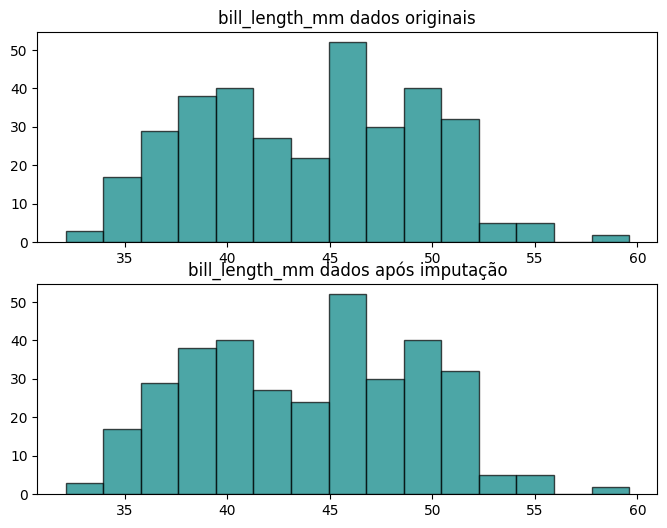

In [ ]:
fig, axes = plt.subplots(2, 1, figsize = (8, 6))

dados_originais = df_original[numeric_cols_list].dropna()
axes[0].hist(dados_originais.bill_length_mm, bins = 15, alpha = 0.7, color = 'teal', edgecolor = 'black')
axes[0].set_title('bill_length_mm dados originais')

axes[1].hist(df_clean.bill_length_mm, bins = 15, alpha = 0.7, color = 'teal', edgecolor = 'black')
axes[1].set_title('bill_length_mm dados após imputação')

plt.show()

In [ ]:
missing_perc_after= df_clean.isnull().mean()*100
missing_perc_after.round(2)

,0
species,0.0
island,0.0
bill_length_mm,0.0
bill_depth_mm,0.0
flipper_length_mm,0.0
body_mass_g,0.0
sex,3.2
sex_imputed,0.0


In [ ]:
#Imputacao de dados em falta concluida
#fluxo:
# - guardar as info dos dados antes da imputacao
# - fazer imputacao
# - guardar as info dos dados depois
# - comparar
# - confirmar se nao existem dados em falta

In [ ]:
#Analise univariavel

In [ ]:
df_clean[numeric_cols_list].describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.443643,1.969027,14.020657,799.613058
min,32.100000,13.100000,172.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.250000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


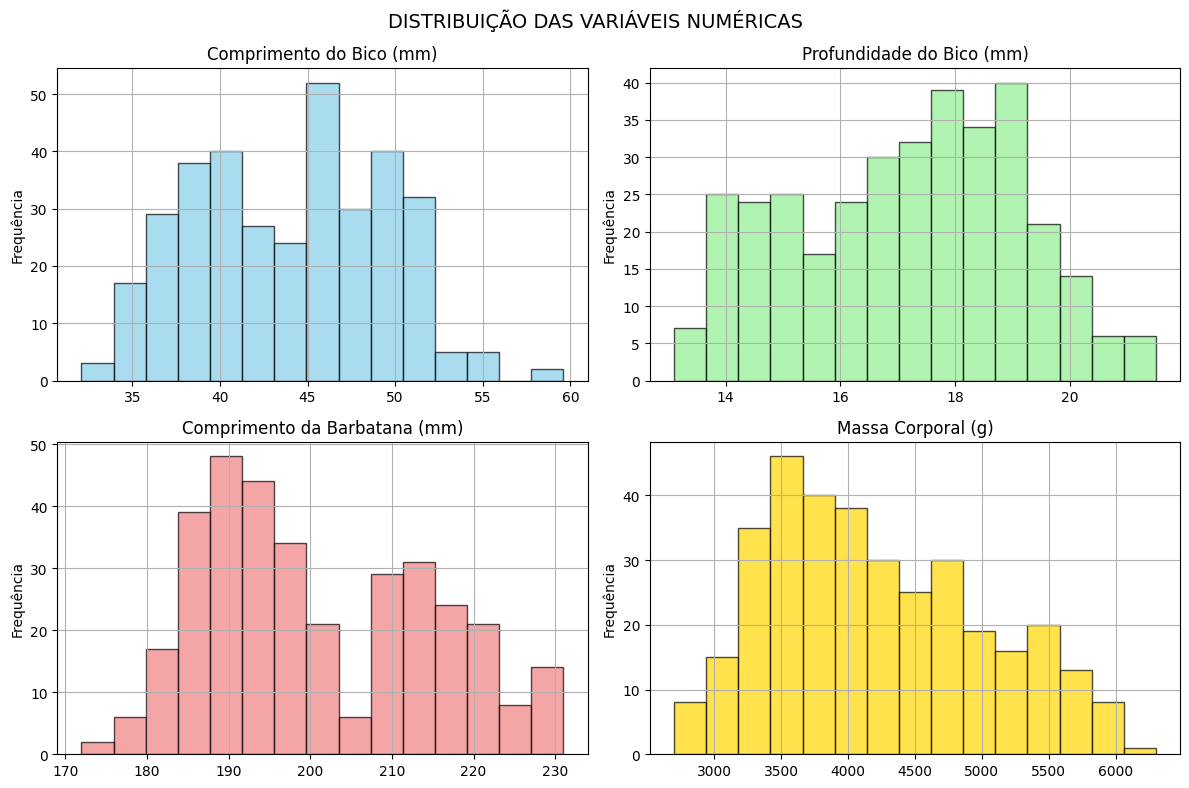

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histograma 1: bill_length_mm
df_clean['bill_length_mm'].hist(ax=axes[0,0], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Comprimento do Bico (mm)')
axes[0,0].set_ylabel('Frequência')

# Histograma 2: bill_depth_mm
df_clean['bill_depth_mm'].hist(ax=axes[0,1], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Profundidade do Bico (mm)')
axes[0,1].set_ylabel('Frequência')

# Histograma 3: flipper_length_mm
df_clean['flipper_length_mm'].hist(ax=axes[1,0], bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,0].set_title('Comprimento da Barbatana (mm)')
axes[1,0].set_ylabel('Frequência')

# Histograma 4: body_mass_g
df_clean['body_mass_g'].hist(ax=axes[1,1], bins=15, alpha=0.7, color='gold', edgecolor='black')
axes[1,1].set_title('Massa Corporal (g)')
axes[1,1].set_ylabel('Frequência')

plt.suptitle('DISTRIBUIÇÃO DAS VARIÁVEIS NUMÉRICAS', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# as variaveis nao seguem a distribuicao normal

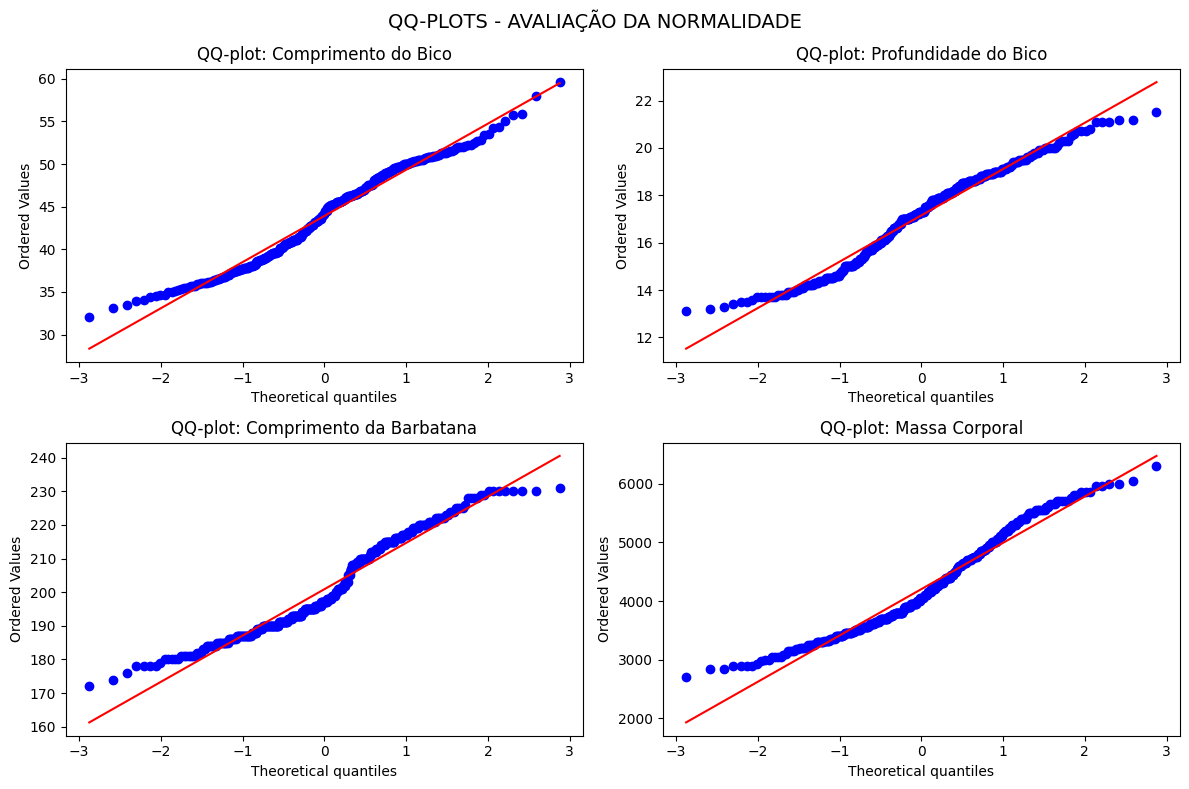

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

import scipy.stats as stats
# QQ-plot para cada variável
stats.probplot(df_clean['bill_length_mm'], dist="norm", plot=axes[0,0])
axes[0,0].set_title('QQ-plot: Comprimento do Bico')

stats.probplot(df_clean['bill_depth_mm'], dist="norm", plot=axes[0,1])
axes[0,1].set_title('QQ-plot: Profundidade do Bico')

stats.probplot(df_clean['flipper_length_mm'], dist="norm", plot=axes[1,0])
axes[1,0].set_title('QQ-plot: Comprimento da Barbatana')

stats.probplot(df_clean['body_mass_g'], dist="norm", plot=axes[1,1])
axes[1,1].set_title('QQ-plot: Massa Corporal')

plt.suptitle('QQ-PLOTS - AVALIAÇÃO DA NORMALIDADE', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


In [ ]:
print('\n' + '='*60)
print('📏 VERIFICAÇÃO DA NORMALIDADE DAS VARIÁVEIS NUMÉRICAS')
print('='*60)

from scipy import stats

print('\n🔍 TESTE DE NORMALIDADE (Shapiro-Wilk):')
print('H0: Os dados seguem uma distribuição normal')
print('H1: Os dados não seguem uma distribuição normal')
print('α = 0.05')

# Teste de Shapiro-Wilk para cada variável
resultados_normalidade = []

for coluna in numeric_cols:
    stat, p_value = stats.shapiro(df_clean[coluna])
    resultados_normalidade.append({
        'Variável': coluna,
        'Estatística': stat,
        'p-value': p_value,
        'Normalidade': 'SIM' if p_value > 0.05 else 'NÃO'
    })

# Criar DataFrame com resultados
df_normalidade = pd.DataFrame(resultados_normalidade)
print('\n📊 RESULTADOS DO TESTE DE SHAPIRO-WILK:')
resultados_normalidade_df = pd.DataFrame(resultados_normalidade).round(3)
display(resultados_normalidade_df)



📏 VERIFICAÇÃO DA NORMALIDADE DAS VARIÁVEIS NUMÉRICAS

🔍 TESTE DE NORMALIDADE (Shapiro-Wilk):
H0: Os dados seguem uma distribuição normal
H1: Os dados não seguem uma distribuição normal
α = 0.05

📊 RESULTADOS DO TESTE DE SHAPIRO-WILK:


,Variável,Estatística,p-value,Normalidade
0,bill_length_mm,0.976,0.0,NÃO
1,bill_depth_mm,0.973,0.0,NÃO
2,flipper_length_mm,0.953,0.0,NÃO
3,body_mass_g,0.960,0.0,NÃO


In [ ]:
df_clean[categorical_cols_list].describe()

,species,island,sex
count,344,344,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,168


In [ ]:
df_clean.describe(include=object)

,species,island,sex,sex_imputed
count,344,344,333,344
unique,3,3,2,2
top,Adelie,Biscoe,Male,Male
freq,152,168,168,179


In [ ]:
#Distribuicao especies
print(df_clean.species.value_counts())
print(df_clean.species.nunique())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
3


In [ ]:
#Distribuicao ilhas
print(df_clean.island.value_counts())
print(df_clean.island.nunique())

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
3


In [ ]:
#Distribuição Género
print(df_clean.sex_imputed.value_counts())
print(df_clean.sex_imputed.nunique())

sex_imputed
Male      179
Female    165
Name: count, dtype: int64
2


In [ ]:
#Proporcao
df_clean.species.value_counts(normalize=True).round(3)*100

,proportion
species,
Adelie,44.2
Gentoo,36.0
Chinstrap,19.8


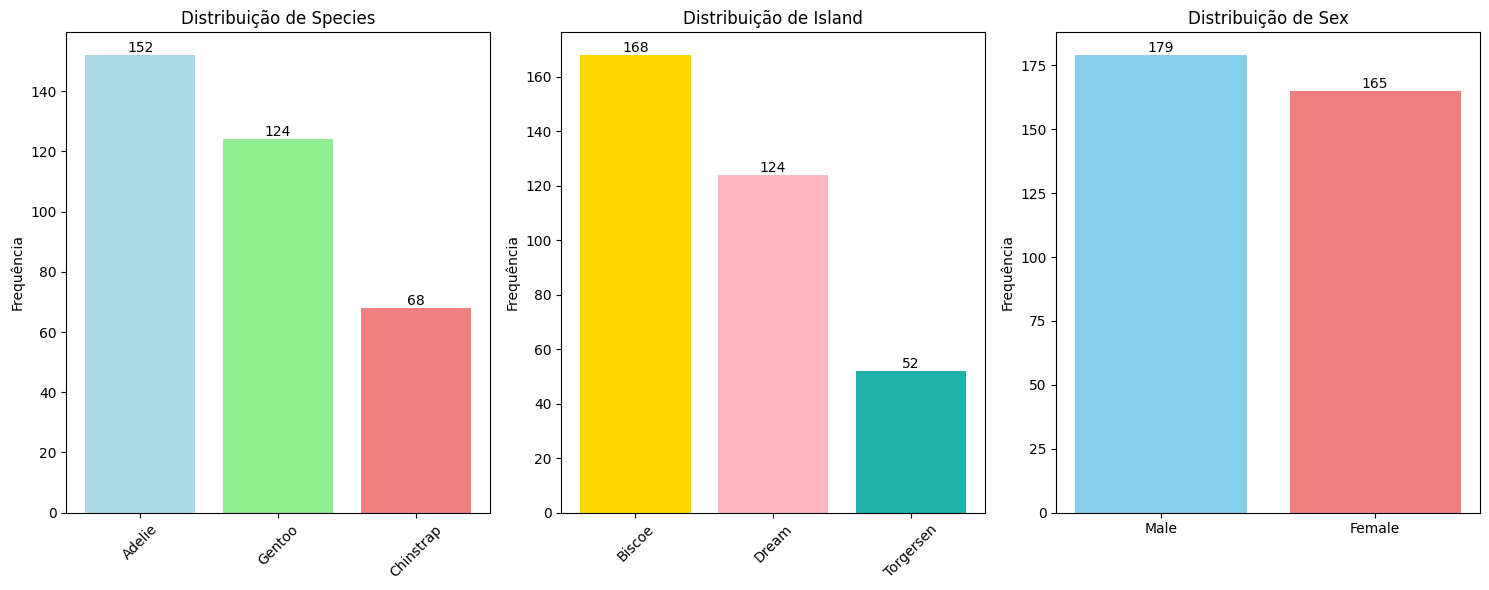

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Gráfico 1: Espécies
contagem_especies = df_clean['species'].value_counts()
bars1 = axes[0].bar(contagem_especies.index, contagem_especies.values, color=['lightblue', 'lightgreen', 'lightcoral'])
axes[0].set_title('Distribuição de Species')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=45)
axes[0].bar_label(bars1)

# Gráfico 2: Island
contagem_ilhas = df_clean['island'].value_counts()
bars2 = axes[1].bar(contagem_ilhas.index, contagem_ilhas.values, color=['gold', 'lightpink', 'lightseagreen'])
axes[1].set_title('Distribuição de Island')
axes[1].set_ylabel('Frequência')
axes[1].tick_params(axis='x', rotation=45)
axes[1].bar_label(bars2)

# Gráfico 3: Sex
contagem_sexos = df_clean['sex_imputed'].value_counts()
bars3 = axes[2].bar(contagem_sexos.index, contagem_sexos.values, color=['skyblue', 'lightcoral'])
axes[2].set_title('Distribuição de Sex')
axes[2].set_ylabel('Frequência')
axes[2].tick_params(axis='x', rotation=0)
axes[2].bar_label(bars3)

plt.tight_layout()

# Remove as linhas de grid
for ax in axes:
    ax.grid(False)

plt.show()


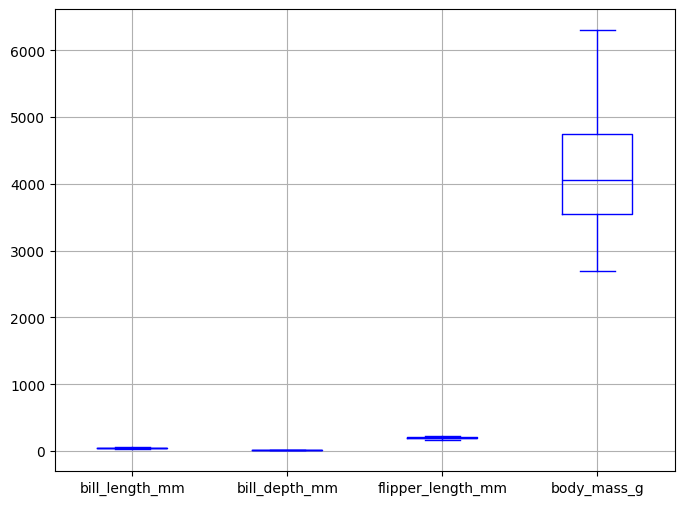

In [ ]:
plt.figure(figsize = (8, 6))

df_clean[numeric_cols_list].boxplot(color = 'blue')

plt.show()

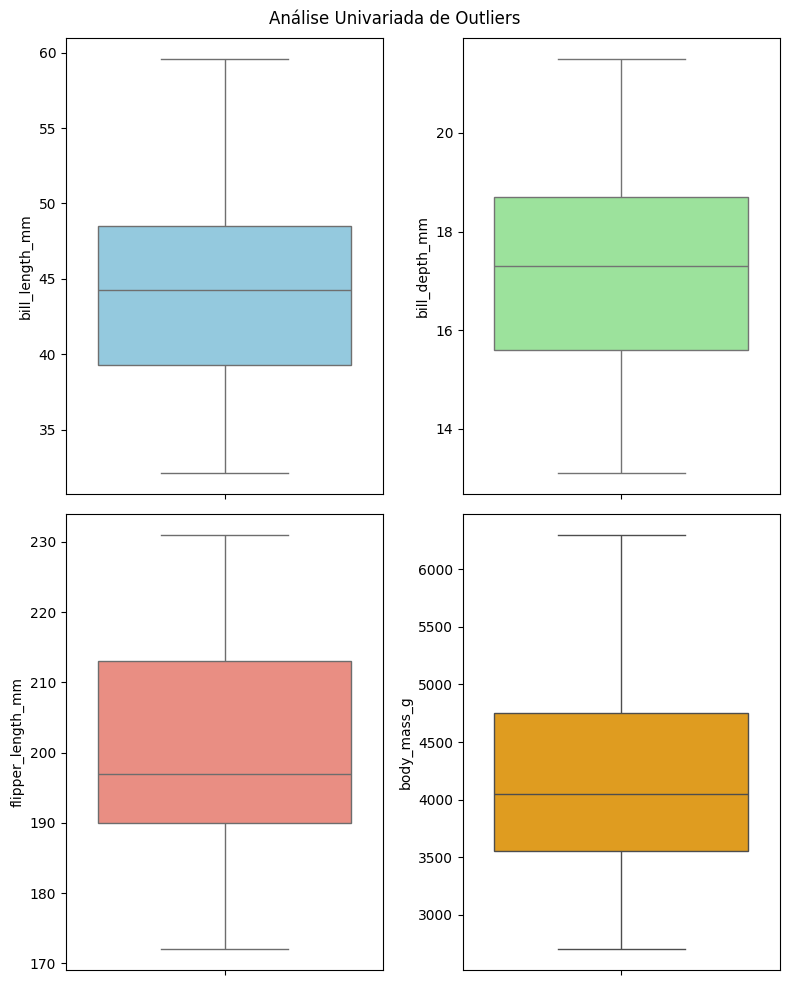

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 10))
fig.suptitle('Análise Univariada de Outliers')

# Boxplots com cores personalizadas
sns.boxplot(data=df_clean, y='bill_length_mm', ax=axes[0,0], color='skyblue')
sns.boxplot(data=df_clean, y='bill_depth_mm', ax=axes[0,1], color='lightgreen')
sns.boxplot(data=df_clean, y='flipper_length_mm', ax=axes[1,0], color='salmon')
sns.boxplot(data=df_clean, y='body_mass_g', ax=axes[1,1], color='orange')

plt.tight_layout()
plt.show()

In [ ]:
#Nao existem outliers univariados mas deve ser confirmado com teste estatistico

In [ ]:
# Calcular outliers usando IQR
Q1 = df_clean[numeric_cols_list].quantile(0.25)
Q3 = df_clean[numeric_cols_list].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('\n🚨 LIMITES PARA DETECÇÃO DE OUTLIERS:')
limites_df = pd.DataFrame({
    'Limite_Inferior': limite_inferior.round(2),
    'Limite_Superior': limite_superior.round(2)
})
print(limites_df)

# Identificar outliers
outliers = (df_clean[numeric_cols_list] < limite_inferior) | (df_clean[numeric_cols_list] > limite_superior)
contagem_outliers = outliers.sum()

print('\n📊 OUTLIERS UNIVARIADOS IDENTIFICADOS POR VARIÁVEL:')
print(contagem_outliers)


🚨 LIMITES PARA DETECÇÃO DE OUTLIERS:
                   Limite_Inferior  Limite_Superior
bill_length_mm               25.44            62.34
bill_depth_mm                10.95            23.35
flipper_length_mm           155.50           247.50
body_mass_g                1750.00          6550.00

📊 OUTLIERS UNIVARIADOS IDENTIFICADOS POR VARIÁVEL:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


In [ ]:
#Analise Bivariada

In [ ]:
#Correlacoes

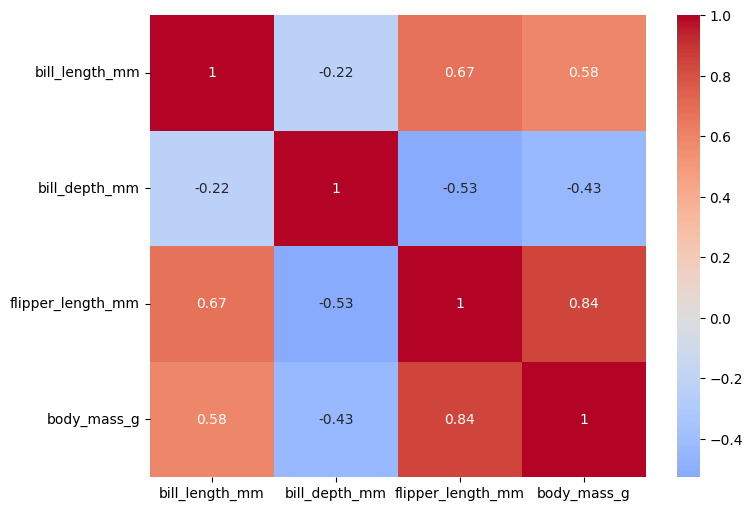

In [ ]:
#corr() -por padrao, vai ser aplicada acorrelacao de Pearson. Person eh a correlacao universao quando a distribuicao dedados eh normal
#Comoos dados nao tem distribuicao normal, aplica-se coeficiente de Spearman

correlacao = df_clean[numeric_cols_list].corr(method = 'spearman')
plt.figure(figsize= (8,6))

sns.heatmap(correlacao, annot = True, cmap= 'coolwarm', center = 0)
plt.show()

In [ ]:
!pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 8.1 MB/s eta 0:00:00


In [ ]:
def outliers_por_especie(especie, variavel):
    '''Encontra outliers para uma variável numa espécie específica'''
    dados = df_clean[df_clean['species'] == especie][variavel]

    Q1 = dados.quantile(0.25)
    Q3 = dados.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dados[(dados < limite_inferior) | (dados > limite_superior)]
    return outliers

# ANÁLISE DE OUTLIERS
print('=' * 50)
print('ANÁLISE DE OUTLIERS UNIVARIADOS POR ESPÉCIE')
print('=' * 50)

for especie in df_clean['species'].unique():
    print(f'\n🐧 **{especie.upper()}**')
    print('-' * 30)

    for variavel in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
        outliers = outliers_por_especie(especie, variavel)
        print(f'{variavel}: {len(outliers)} outliers')

print('\n' + '=' * 50)
print('OUTLIERS BIVARIADOS - COMPRIMENTO vs PROFUNDIDADE DO BICO')
print('=' * 50)

# Primeiro: marcar todos os outliers univariados
df_clean['outlier_bill_length'] = False
df_clean['outlier_bill_depth'] = False

for especie in df_clean['species'].unique():
    # Marcar outliers no comprimento do bico
    outliers_length = outliers_por_especie(especie, 'bill_length_mm')
    df_clean.loc[outliers_length.index, 'outlier_bill_length'] = True

    # Marcar outliers na profundidade do bico
    outliers_depth = outliers_por_especie(especie, 'bill_depth_mm')
    df_clean.loc[outliers_depth.index, 'outlier_bill_depth'] = True

# Criar coluna para outliers bivariados
df_clean['outlier_bivariado'] = df_clean['outlier_bill_length'] | df_clean['outlier_bill_depth']

# Mostrar resultados
for especie in df_clean['species'].unique():
    dados_especie = df_clean[df_clean['species'] == especie]
    n_outliers = dados_especie['outlier_bivariado'].sum()

    print(f'\n{especie}: {n_outliers} outliers bivariados')

    if n_outliers > 0:
        outliers_data = dados_especie[dados_especie['outlier_bivariado']]
        for idx, row in outliers_data.iterrows():
            print(f'   • Bico: {row["bill_length_mm"]:.1f}mm, Profundidade: {row["bill_depth_mm"]:.1f}mm')


ANÁLISE DE OUTLIERS UNIVARIADOS POR ESPÉCIE

🐧 **ADELIE**
------------------------------
bill_length_mm: 0 outliers
bill_depth_mm: 1 outliers
flipper_length_mm: 2 outliers
body_mass_g: 0 outliers

🐧 **CHINSTRAP**
------------------------------
bill_length_mm: 0 outliers
bill_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 2 outliers

🐧 **GENTOO**
------------------------------
bill_length_mm: 1 outliers
bill_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers

OUTLIERS BIVARIADOS - COMPRIMENTO vs PROFUNDIDADE DO BICO

Adelie: 1 outliers bivariados
   • Bico: 46.0mm, Profundidade: 21.5mm

Chinstrap: 0 outliers bivariados

Gentoo: 1 outliers bivariados
   • Bico: 59.6mm, Profundidade: 17.0mm


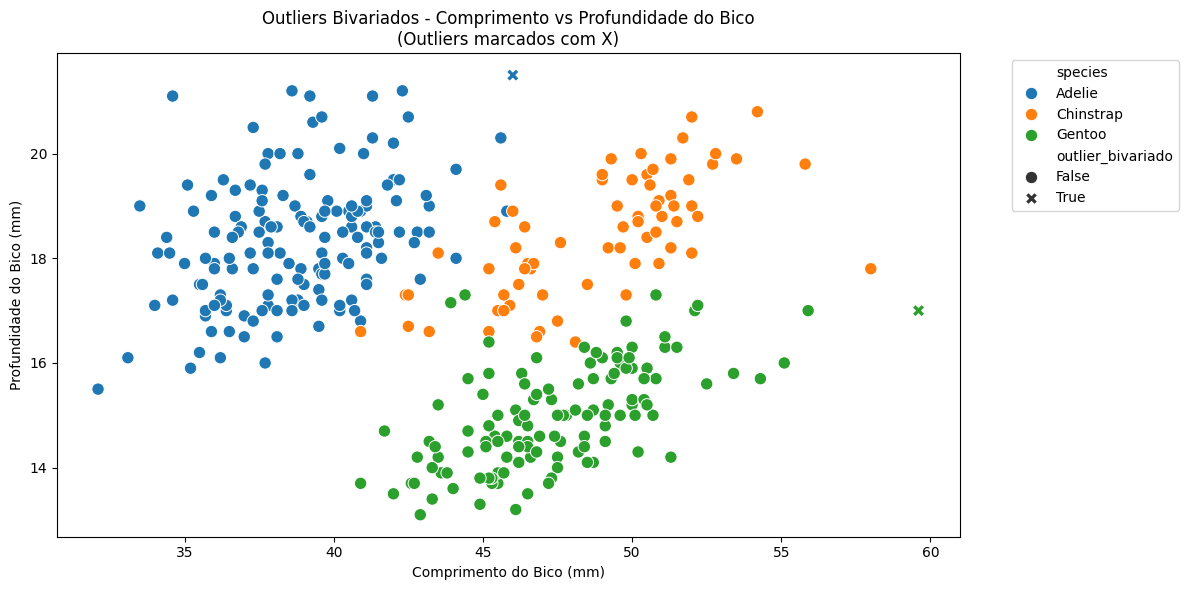


RESUMO FINAL
Total de pinguins analisados: 344
Total de outliers bivariados encontrados: 2
Percentagem de outliers: 0.6%


In [ ]:
plt.figure(figsize=(12, 6))

# Criar scatter plot com outliers destacados
scatter = sns.scatterplot(
    data=df_clean,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',
    style='outlier_bivariado',
    s=80,
    markers={False: 'o', True: 'X'}
)

plt.title('Outliers Bivariados - Comprimento vs Profundidade do Bico\n(Outliers marcados com X)')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Profundidade do Bico (mm)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 6. RESUMO FINAL
print('\n' + '=' * 50)
print('RESUMO FINAL')
print('=' * 50)

total_outliers = df_clean['outlier_bivariado'].sum()
total_pinguins = len(df_clean)

print(f'Total de pinguins analisados: {total_pinguins}')
print(f'Total de outliers bivariados encontrados: {total_outliers}')
print(f'Percentagem de outliers: {(total_outliers/total_pinguins)*100:.1f}%')

In [ ]:
#Decisão Outliers:

#Trata-se de um data set científico, pouca probabilidade de serem erros de medição.

#Assume-se que te tratam de registos que representam a diversidade da natureza.

#E face à proporção, opta-se pela não remoção dos outliers identificados.

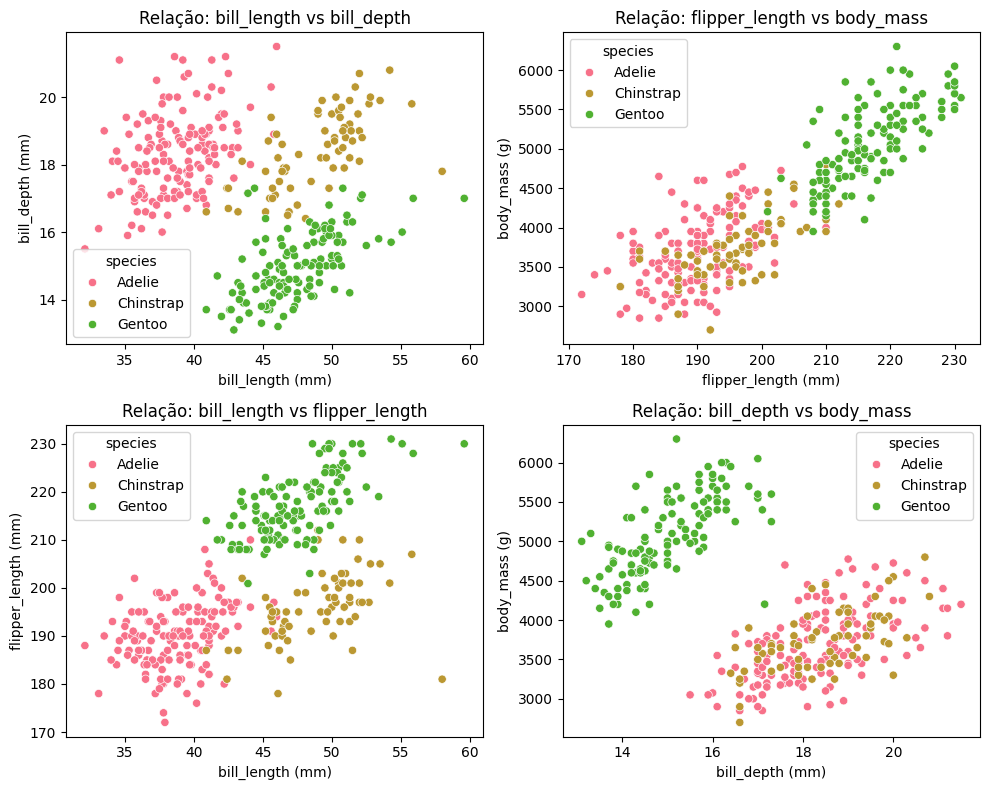

In [ ]:
# Configurar o estilo dos gráficos
plt.style.use('default')
sns.set_palette('husl')

# A partir do momento que usamos o set_pallete,
# esta palete de cores vai ser aplicada em todos os gráicos.

# Criar uma figura com múltiplos scatter plots
fig = plt.figure(figsize=(10, 8))

# Plot 1: bill_length vs bill_depth
plt.subplot(2, 2, 1)
sns.scatterplot(data=df_clean, x='bill_length_mm', y='bill_depth_mm', hue='species')
plt.title('Relação: bill_length vs bill_depth')
plt.xlabel('bill_length (mm)')
plt.ylabel('bill_depth (mm)')

# Plot 2: flipper_length vs body_mass
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_clean, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Relação: flipper_length vs body_mass')
plt.xlabel('flipper_length (mm)')
plt.ylabel('body_mass (g)')

# Plot 3: bill_length vs flipper_length
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_clean, x='bill_length_mm', y='flipper_length_mm', hue='species')
plt.title('Relação: bill_length vs flipper_length')
plt.xlabel('bill_length (mm)')
plt.ylabel('flipper_length (mm)')

# Plot 4: bill_depth vs body_mass
plt.subplot(2, 2, 4)
sns.scatterplot(data=df_clean, x='bill_depth_mm', y='body_mass_g', hue='species')
plt.title('Relação: bill_depth vs body_mass')
plt.xlabel('bill_depth (mm)')
plt.ylabel('body_mass (g)')

plt.tight_layout()
plt.show()


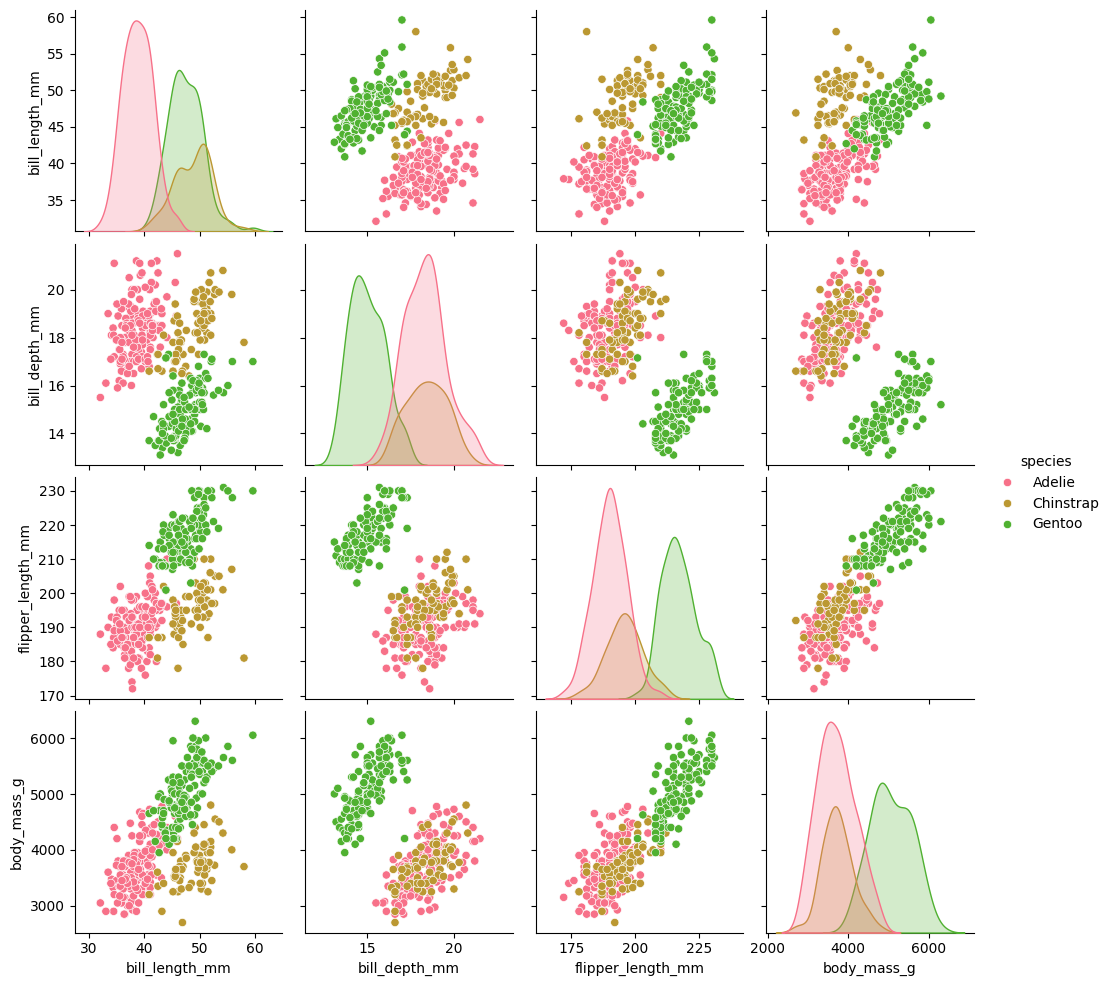

In [ ]:
sns.pairplot(df_clean, vars = numeric_cols_list, hue = 'species')
plt.show()

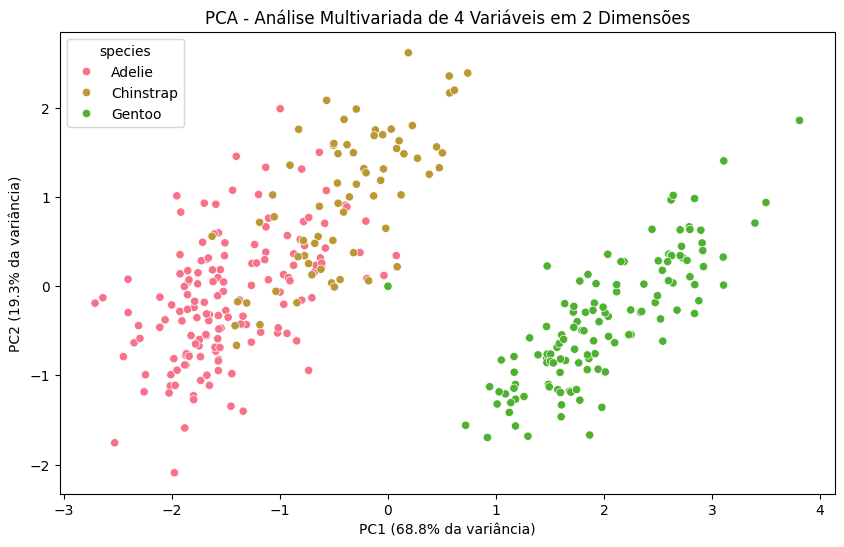

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preparar os dados (remover missing values)
dados_completos = df_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna()
especies = df_clean.loc[dados_completos.index, 'species']

# Padronizar os dados
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(dados_completos)

# Aplicar PCA
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(dados_padronizados)

# Criar DataFrame com resultados
pca_df = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
pca_df['species'] = especies.values

# Visualizar
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='species')
plt.title('PCA - Análise Multivariada de 4 Variáveis em 2 Dimensões')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
plt.show()


In [ ]:
print('ANÁLISE DOS RESULTADOS DO PCA')
print('=' * 60)

print(f'\n📈 VARIABILIDADE EXPLICADA:')
print(f'• PC1: {pca.explained_variance_ratio_[0]:.1%} da variabilidade')
print(f'• PC2: {pca.explained_variance_ratio_[1]:.1%} da variabilidade')
print(f'• TOTAL: {pca.explained_variance_ratio_.sum():.1%} da variabilidade total')

print(f'\n🎯 SIGNIFICADO PRÁTICO:')
print(f'• Com apenas 2 dimensões (PC1 + PC2), capturamos {pca.explained_variance_ratio_.sum():.1%} de toda a informação')
print(f'• Isto é EXCELENTE - perdemos apenas {100-pca.explained_variance_ratio_.sum()*100:.1f}% da informação original')


ANÁLISE DOS RESULTADOS DO PCA

📈 VARIABILIDADE EXPLICADA:
• PC1: 68.8% da variabilidade
• PC2: 19.3% da variabilidade
• TOTAL: 88.2% da variabilidade total

🎯 SIGNIFICADO PRÁTICO:
• Com apenas 2 dimensões (PC1 + PC2), capturamos 88.2% de toda a informação
• Isto é EXCELENTE - perdemos apenas 11.8% da informação original


In [ ]:
# Ver os pesos de cada variável nos componentes
print('\n🔧 COMPOSIÇÃO DOS COMPONENTES PRINCIPAIS:')
componentes_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
)

print(componentes_df.round(3))


🔧 COMPOSIÇÃO DOS COMPONENTES PRINCIPAIS:
                     PC1    PC2
bill_length_mm     0.455  0.597
bill_depth_mm     -0.400  0.798
flipper_length_mm  0.576  0.002
body_mass_g        0.548  0.084


In [ ]:
#Pré-processamento dos Dados

In [ ]:
#Codificar asvariáveiscategoricas

In [ ]:
df_clean.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'sex_imputed',
       'outlier_bill_length', 'outlier_bill_depth', 'outlier_bivariado'],
      dtype='object')

In [ ]:
df_clean = df_clean.drop(['outlier_bill_length', 'outlier_bill_depth', 'outlier_bivariado', 'sex'], axis = 1)

In [ ]:
df_clean.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_imputed
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [ ]:
df_clean.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex_imputed'],
      dtype='object')

In [ ]:
df_processed = pd.get_dummies(df_clean, columns = ['species', 'island','sex_imputed'])
df_processed.head().T


,0,1,2,3,4
bill_length_mm,39.1,39.5,40.3,43.92193,36.7
bill_depth_mm,18.7,17.4,18.0,17.15117,19.3
flipper_length_mm,181.0,186.0,195.0,200.915205,193.0
body_mass_g,3750.0,3800.0,3250.0,4201.754386,3450.0
species_Adelie,True,True,True,True,True
species_Chinstrap,False,False,False,False,False
species_Gentoo,False,False,False,False,False
island_Biscoe,False,False,False,False,False
island_Dream,False,False,False,False,False
island_Torgersen,True,True,True,True,True


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
df_processed[numeric_cols_list] = StandardScaler().fit_transform(df_processed[numeric_cols_list])

In [ ]:
df_processed.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.00,344.00,344.00,344.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-2.17,-2.06,-2.07,-1.88
25%,-0.85,-0.79,-0.78,-0.82
50%,0.06,0.08,-0.28,-0.19
75%,0.84,0.79,0.86,0.69
max,2.88,2.21,2.15,2.63
